Problem statement: whenever we order food from food delivery apps like Swiggy, Zomato, etc.. it shows us an expected time (like 25mins, 45 mins, etc).
The question is how is the time estimated? In the backend, a machine learning algorithm which has been trained on historical data is applied and then from that we predict the expected time to deliver order. This eventually boils down to a regression problem and on the basis of that the ML algo predicts the time based on data points.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
train_df=pd.read_csv('/content/train.csv')


In [ ]:
train_df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

The motivation of this project for me is to predict the time taken by the delivery person to deliver an order. So the last column becomes our output feature and the rest becomes our input feature.

-> There are no null values in this datset in any column.

-> As visible in the "Dtype" column of train_df.info(), some of the columns have Dtype as 'object' when it should have been integer type, like age, rating, etc.
The order data should have been a date_time dtype.

In [ ]:
train_df['multiple_deliveries'].value_counts()

,count
multiple_deliveries,
1,28159
0,14095
2,1985
NaN,993
3,361


-> Thing to note carefully here is the NaN is being treated as a string rather than actual Nan value. This is why it showed that there are no NaN values when there actually exists a lot of missing balues.

Now we need to tackle this for all the columns, we will have a look at it one by one for every column.

In [ ]:
train_df.select_dtypes(include='object').columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival',
       'City', 'Time_taken(min)'],
      dtype='object')

The output feature is also being treated as dtype object. We need to change a lot of things here in order for the data to make sense.

Things we need to do
1) NaN string -> np.nan
2) If we do have string somewhere, we need to clean it as well (rstrip, lstrip etc)
3) Need to fix the dtype of output variable as well.
4) In Weatherconditions column, we do not require the string "conditions" to be written before every value in column

In [ ]:
train_df['Weatherconditions']=train_df['Weatherconditions'].apply(
    lambda x:x.split(" ")[1] if pd.notnull(x) else x)

In [ ]:
train_df['Weatherconditions'].value_counts()

,count
Weatherconditions,
Fog,7654
Stormy,7586
Cloudy,7536
Sandstorms,7495
Windy,7422
Sunny,7284
NaN,616


In [ ]:
for col in train_df.select_dtypes(include='object').columns:
  train_df[col]=train_df[col].str.strip()
  train_df[col]=train_df[col].replace('NaN',np.nan)

In [ ]:
train_df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [ ]:
train_df['multiple_deliveries'].value_counts()

,count
multiple_deliveries,
1,28159
0,14095
2,1985
3,361


In [ ]:
train_df['Time_taken(min)'].str.split(" ")

,Time_taken(min)
0,"[(min), 24]"
1,"[(min), 33]"
2,"[(min), 26]"
3,"[(min), 21]"
4,"[(min), 30]"
...,...
45588,"[(min), 32]"
45589,"[(min), 36]"
45590,"[(min), 16]"
45591,"[(min), 26]"


In [ ]:
train_df['Time_taken(min)']=train_df['Time_taken(min)'].apply(
    lambda x:int(x.split(" ")[1]) if pd.notnull(x) else x)

In [ ]:
train_df['Time_taken(min)'].describe()

,Time_taken(min)
count,45593.000000
mean,26.294607
std,9.383806
min,10.000000
25%,19.000000
50%,26.000000
75%,32.000000
max,54.000000


Now the dtype is float. Good.

There is no column for output variable in test dataset.

Some features like age of the delivery person, rating and the count of how many deliveries they made should be an numeric rather than a string.

In [ ]:
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries']:
  train_df[col]=pd.to_numeric(train_df[col],errors='coerce')
  # test_df[col]=pd.to_numeric(test_df[col],errors='coerce')


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          43739 non-null  float64
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            44977 non-null  object 
 12  Road_traffic_density         44992 non-null  object 
 13  Vehicle_conditio

In [ ]:
train_df['Festival'].value_counts()

,count
Festival,
No,44469
Yes,896


In [ ]:
train_df['Type_of_vehicle'].value_counts()

,count
Type_of_vehicle,
motorcycle,26435
scooter,15276
electric_scooter,3814
bicycle,68


Filling missing values now.
The numeric featues, generally can be filled by median or average. The categorical features can be filled by mode of them.  

In [ ]:
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries']:
  train_df[col].fillna(train_df[col].median(),inplace=True)

In [ ]:
for col in ['City','Festival','Road_traffic_density','Weatherconditions']:
  train_df[col].fillna(train_df[col].mode()[0],inplace=True)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [ ]:
train_df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30


Time_Orderd, Time_Order_picked should be converted to datetime object

In [ ]:
train_df['order_time_object']=pd.to_datetime(train_df['Time_Orderd'],format='%H:%M:%S',errors='coerce')


In [ ]:
train_df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_time_object
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,1900-01-01 11:30:00
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,1900-01-01 19:45:00
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,1900-01-01 08:30:00
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,1900-01-01 18:00:00
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,1900-01-01 13:30:00


In [ ]:
train_df['order_hour']=train_df['order_time_object'].dt.hour

In [ ]:
train_df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_time_object,order_hour
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,High,2,Snack,motorcycle,0.0,No,Urban,24,1900-01-01 11:30:00,11.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,1900-01-01 19:45:00,19.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Low,0,Drinks,motorcycle,1.0,No,Urban,26,1900-01-01 08:30:00,8.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,1900-01-01 18:00:00,18.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,High,1,Snack,scooter,1.0,No,Metropolitian,30,1900-01-01 13:30:00,13.0


In [ ]:
train_df['order_hour'].fillna(train_df['order_hour'].median(),inplace=True)

In [ ]:
train_df.drop(columns=['order_time_object'],inplace=True)

In [ ]:
train_df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_hour
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,11.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,19.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,8.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,18.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,13.0


In [ ]:
def calculate_series_distance(
    lat1_series, lon1_series, lat2_series, lon2_series, miles=False
):
    """Calculates the great-circle distance between two series of points

    using the vectorised Haversine formula on NumPy arrays.
    """
    # Earth's radius: 6371 km or 3956 miles
    R = 3956.0 if miles else 6371.0

    # Convert all pandas Series to NumPy arrays in radians
    phi1 = np.radians(lat1_series.to_numpy())
    phi2 = np.radians(lat2_series.to_numpy())
    delta_phi = np.radians(
        (lat2_series - lat1_series).to_numpy()
    )  # Fixed syntax error from image
    delta_lambda = np.radians((lon2_series - lon1_series).to_numpy())

    # Haversine formula component calculations
    a = (
        np.sin(delta_phi / 2.0) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0) ** 2
    )

    # Compute the arc distance
    c = 2.0 * np.arcsin(np.sqrt(a))

    # Return as a pandas Series preserving the original index
    return pd.Series(R * c, index=lat1_series.index)

In [ ]:
train_df['distance_km']=calculate_series_distance(train_df['Restaurant_latitude'],train_df['Restaurant_longitude'],train_df['Delivery_location_latitude'],train_df['Delivery_location_longitude'])

In [ ]:
train_df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_hour,distance_km
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,High,2,Snack,motorcycle,0.0,No,Urban,24,11.0,3.025149
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,19.0,20.183530
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Low,0,Drinks,motorcycle,1.0,No,Urban,26,8.0,1.552758
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,18.0,7.790401
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,High,1,Snack,scooter,1.0,No,Metropolitian,30,13.0,6.210138


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

Time to build our indicator matrix from training dataset

In [ ]:
features=['Delivery_person_Age','Delivery_person_Ratings','distance_km','order_hour','Weatherconditions','Road_traffic_density','Vehicle_condition','Type_of_order','Type_of_vehicle','multiple_deliveries','Festival','City']

In [ ]:
X=train_df[features]
Y=train_df['Time_taken(min)']

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Delivery_person_Age      45593 non-null  float64
 1   Delivery_person_Ratings  45593 non-null  float64
 2   distance_km              45593 non-null  float64
 3   order_hour               45593 non-null  float64
 4   Weatherconditions        45593 non-null  object 
 5   Road_traffic_density     45593 non-null  object 
 6   Vehicle_condition        45593 non-null  int64  
 7   Type_of_order            45593 non-null  object 
 8   Type_of_vehicle          45593 non-null  object 
 9   multiple_deliveries      45593 non-null  float64
 10  Festival                 45593 non-null  object 
 11  City                     45593 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usage: 4.2+ MB


We need analyze every feature one by one. Why?
Let's suppose we have a numerical feature we get an idea about if the data is clean or not, whether we need to replace it or not. Whether there exists a linear relationship among input features, etc.
And how it affects the output variable.


One more thing to note is that when we are applying a regression model which is sensitive to outliers like linear regression in that case its better that we take of outliers.

Lets start with the feature that actually looks very much important to delivery time, which the distance_km.


In [ ]:
X['distance_km'].describe()

,distance_km
count,45593.000000
mean,99.303911
std,1099.731281
min,1.465067
25%,4.663493
50%,9.264281
75%,13.763977
max,19692.674606


Got exactly what we looked for, even if we are being generous about the distance that a delivery person travels for a single delivery, we can expect the max to be around 50 to 100km, but here as we see that the 75th percentile value is around 13km while the max value is 20 thousand km which is obviously showing that this particular data point is absolutely wrong.

The distance data has some problems. We need to have a look at the distribution and understand how many such values are there.

In [ ]:
X['distance_km'].sort_values().tail(432)

,distance_km
15710,20.969489
2138,2216.065794
23588,2220.724619
5992,2222.078040
28943,2222.608036
...,...
9535,19070.408110
18826,19677.180552
2484,19683.687561
6788,19688.001288


Clearly this shows that there a LOTS of data points which aren't correct.

In [ ]:
X[X['distance_km']>100]

,Delivery_person_Age,Delivery_person_Ratings,distance_km,order_hour,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
92,34.0,4.7,6048.631240,23.0,Sandstorms,Low,1,Drinks,scooter,0.0,No,Metropolitian
283,32.0,4.7,6047.919478,20.0,Sandstorms,Jam,2,Meal,scooter,1.0,No,Metropolitian
289,30.0,4.7,16612.239055,19.0,Stormy,Jam,2,Meal,scooter,0.0,No,Urban
425,30.0,4.7,17744.205087,19.0,Fog,Low,3,Snack,scooter,1.0,No,Metropolitian
534,30.0,4.7,17118.828366,19.0,Fog,Low,3,Buffet,scooter,1.0,No,Metropolitian
...,...,...,...,...,...,...,...,...,...,...,...,...
44933,30.0,4.9,4423.276011,22.0,Fog,Low,1,Buffet,motorcycle,0.0,No,Metropolitian
45020,30.0,4.7,4118.484540,19.0,Fog,Low,3,Drinks,electric_scooter,1.0,No,Metropolitian
45108,30.0,4.7,16560.629487,19.0,Windy,Jam,2,Meal,scooter,1.0,No,Urban
45182,30.0,4.0,5895.019482,22.0,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Metropolitian


431 data points have problems based on the distance we calculated from the coordinates we found in the data. Almost 1% of data.

Now another problem that arise because of this is that if we try to draw its distribution on a graph, the scale on the X-axis will be a lot larger if we go with histogram, boxplot

<Axes: xlabel='distance_km', ylabel='Count'>

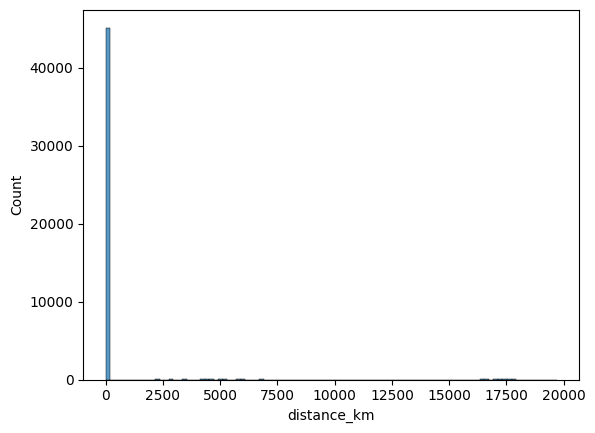

In [ ]:
sns.histplot(X['distance_km'],bins=100)

Clearly the histogram isn't able to capture any information for us to be able to interpret it.

Let's discuss a thing or two about coordinates we got for the data points with distance_km>100.

In [ ]:
train_df[train_df['distance_km']>100]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_hour,distance_km
92,0xc042,AGRRES010DEL01,34.0,4.7,-27.163303,78.057044,27.233303,78.127044,16-02-2022,23:00:00,...,Low,1,Drinks,scooter,0.0,No,Metropolitian,15,23.0,6048.631240
283,0xc044,AGRRES12DEL03,32.0,4.7,-27.165108,78.015053,27.225108,78.075053,13-02-2022,20:55:00,...,Jam,2,Meal,scooter,1.0,No,Metropolitian,31,20.0,6047.919478
289,0x4db,PUNERES02DEL03,30.0,4.7,-18.551440,-73.804855,18.611440,73.864855,05-03-2022,NaN,...,Jam,2,Meal,scooter,0.0,No,Urban,12,19.0,16612.239055
425,0xc003,DEHRES13DEL02,30.0,4.7,-30.366322,-78.070453,30.496322,78.200453,18-02-2022,NaN,...,Low,3,Snack,scooter,1.0,No,Metropolitian,20,19.0,17744.205087
534,0x473,MYSRES07DEL03,30.0,4.7,-12.325461,-76.632278,12.385461,76.692278,03-03-2022,NaN,...,Low,3,Buffet,scooter,1.0,No,Metropolitian,16,19.0,17118.828366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44933,0xc0c2,AURGRES03DEL03,30.0,4.9,-19.874733,75.353942,19.904733,75.383942,15-02-2022,22:20:00,...,Low,1,Buffet,motorcycle,0.0,No,Metropolitian,15,22.0,4423.276011
45020,0x56b,PUNERES04DEL01,30.0,4.7,-18.514210,73.838429,18.524210,73.848429,21-03-2022,NaN,...,Low,3,Drinks,electric_scooter,1.0,No,Metropolitian,30,19.0,4118.484540
45108,0xc01b,GOARES18DEL01,30.0,4.7,-15.493950,-73.827423,15.563950,73.897423,16-02-2022,NaN,...,Jam,2,Meal,scooter,1.0,No,Urban,19,19.0,16560.629487
45182,0xc0c7,KNPRES16DEL02,30.0,4.0,-26.482581,80.315628,26.532581,80.365628,17-02-2022,22:25:00,...,Low,0,Drinks,motorcycle,1.0,No,Metropolitian,34,22.0,5895.019482


When we change the coordinates by mere decimal value we can observe a change of a few kilometers.
Here when we looked at the restaurant latitude and delivery location latitude we can observe a few things-
1) In the very first data point it is visible that restaurant latitude was -27 while delivery location is +27. A mere change of a few decimals gives a distance of a few kilometers, a change in sign has the potential to directly change the hemishpere. So this is probably a mistake made during data collection. This is one of the possible reason.

We do realise that we cannot directly feed a data like this because of so many outliers.

Solution to a problem like this can be
* To remove all the rows (it makes up about 1 % of data )
* We rectify the problem by converting the negative coordinates to positive.


In [ ]:
# We move on with the first option
Y=Y[X['distance_km']<100].reset_index(drop=True)
X=X[X['distance_km']<100].reset_index(drop=True)

In [ ]:
X['distance_km'].describe()

,distance_km
count,45162.000000
mean,9.735396
std,5.608508
min,1.465067
25%,4.663412
50%,9.220209
75%,13.681490
max,20.969489


<Axes: xlabel='distance_km', ylabel='Count'>

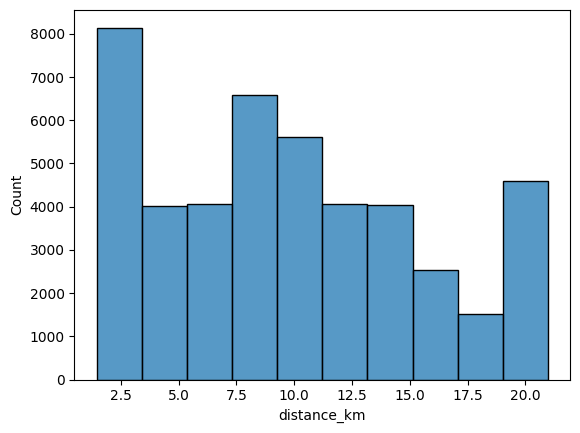

In [ ]:
sns.histplot(X['distance_km'],bins=10)

Before we move ahead, let's check how much correlation does the distance has with the expected delivery time.

In [ ]:
X['distance_km'].corr(Y)

np.float64(0.32170310355298803)

A correlation of 0.32 is not a strong correlation.

This can be due to a lot of reasons like rush hour, festival crowd, etc reasons. Or the existence of a non-linear relationship between them(correlation only checks for linear relationship).

Distance alone does not have a strong direct relationship with time, it's possible that when combined with other features it gives a strong prediction power.

In [ ]:
X['Delivery_person_Age'].describe()

,Delivery_person_Age
count,45162.000000
mean,29.575683
std,5.692344
min,15.000000
25%,25.000000
50%,30.000000
75%,34.000000
max,50.000000


This data column looks practical.

<Axes: xlabel='Delivery_person_Age', ylabel='Count'>

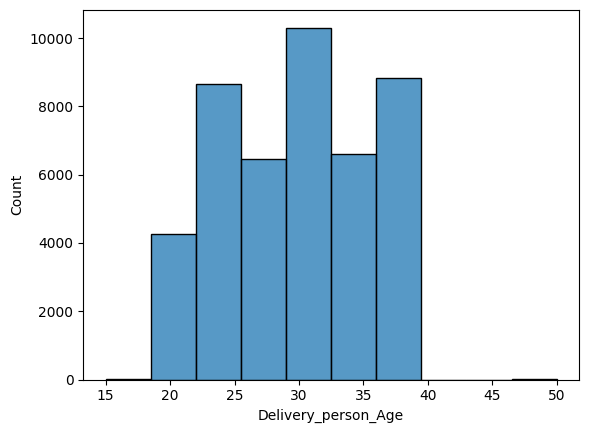

In [ ]:
sns.histplot(X['Delivery_person_Age'],bins=10)

The distribution also looks good, and not very skewed.

In [ ]:
X['Delivery_person_Ratings'].describe()

,Delivery_person_Ratings
count,45162.000000
mean,4.636367
std,0.323078
min,1.000000
25%,4.500000
50%,4.700000
75%,4.800000
max,6.000000


In [ ]:
X[X['Delivery_person_Ratings']>5].shape

(31, 12)

Rating should be from 1 to 5 only

Now what we can do is clip the rating to 5 if rating is greater than 5.

Or we can drop it.

We are clipping it.

In [ ]:
X['Delivery_person_Ratings']=X['Delivery_person_Ratings'].clip(upper=5)

<Axes: xlabel='Delivery_person_Ratings', ylabel='Count'>

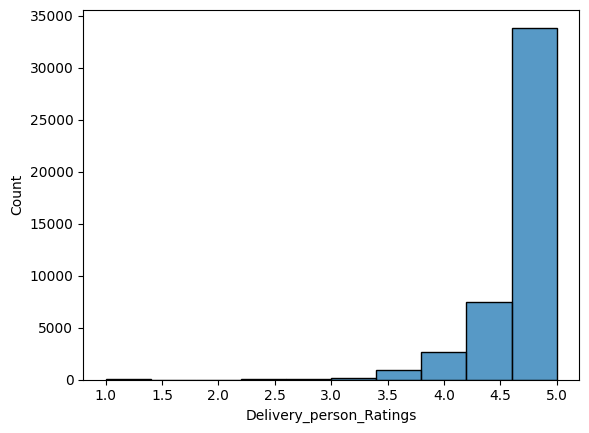

In [ ]:
sns.histplot(X['Delivery_person_Ratings'],bins=10)

Most of the delivery partners rating is good(around 75%+ have 4.5+ rating).

In [ ]:
X['Weatherconditions'].value_counts()

,count
Weatherconditions,
Fog,8071
Stormy,7544
Cloudy,7485
Sandstorms,7442
Windy,7382
Sunny,7238


Need to have a look at whether the weather condition affect the time taken significantly or not.

In [ ]:
temp=X.copy()
temp['time_taken']=Y
temp.groupby('Weatherconditions')['time_taken'].agg(['mean','median','count','std'])

,mean,median,count,std
Weatherconditions,,,,
Cloudy,28.922378,28.0,7485,10.091815
Fog,28.800520,28.0,8071,10.107274
Sandstorms,25.872481,26.0,7442,8.611694
Stormy,25.866384,26.0,7544,8.467728
Sunny,21.854656,20.0,7238,8.317812
Windy,26.127879,26.0,7382,8.621748


Since this is a categorical column we need to convert it to numeric column now.
We will be using nominal one hot encoding (because we are assuming that there is no relative order among weather conditions).

In [ ]:
X=pd.get_dummies(X,columns=['Weatherconditions'],drop_first=True,dtype=int)

What if we don't drop the column Weatherconditions after one hot encoding? To remove the problem of multicollinearity.

Problem of multicollinearity is not found in models like decision trees but it will absolutely affect a model like linear regression (the design matrix have dependent columns leading to infinite solutions).

But see, some models allow collinear features and some don't. It is better to remove the linearly dependent features so that there is no problem in any model that we use whether a linear model or not.


It is the same with feature scaling, although we understand that standard tree based do not care about the scale of the data but its a good practice to have our feature scaled properly.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45162 entries, 0 to 45161
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Delivery_person_Age           45162 non-null  float64
 1   Delivery_person_Ratings       45162 non-null  float64
 2   distance_km                   45162 non-null  float64
 3   order_hour                    45162 non-null  float64
 4   Road_traffic_density          45162 non-null  object 
 5   Vehicle_condition             45162 non-null  int64  
 6   Type_of_order                 45162 non-null  object 
 7   Type_of_vehicle               45162 non-null  object 
 8   multiple_deliveries           45162 non-null  float64
 9   Festival                      45162 non-null  object 
 10  City                          45162 non-null  object 
 11  Weatherconditions_Fog         45162 non-null  int64  
 12  Weatherconditions_Sandstorms  45162 non-null  int64  
 13  W

In [ ]:
X['Road_traffic_density'].value_counts()

,count
Road_traffic_density,
Low,15826
Jam,14050
Medium,10886
High,4400


In [ ]:
temp=X.copy()
temp['time_taken']=Y
temp.groupby('Road_traffic_density')['time_taken'].agg(['mean','median','count','std'])

,mean,median,count,std
Road_traffic_density,,,,
High,27.226364,27.0,4400,8.392894
Jam,31.181637,31.0,14050,9.944191
Low,21.421964,21.0,15826,6.947240
Medium,26.708617,27.0,10886,8.555376


Let's convert this to numeric and then find a correlation of this with time to deliver.

This feature requires ordinal encoding (the relative order is dependent with respect to each other). We need to actually give weightage to increasing traffic as it has effects on time taken.

In [ ]:
TRAFFIC_MAPPING={
    'Low':0,
    'Medium':1,
    'High':2,
    'Jam':3
}
X['Road_traffic_density']=X['Road_traffic_density'].map(TRAFFIC_MAPPING)

In [ ]:
X['Road_traffic_density'].corr(Y)

np.float64(0.4133087970004871)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45162 entries, 0 to 45161
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Delivery_person_Age           45162 non-null  float64
 1   Delivery_person_Ratings       45162 non-null  float64
 2   distance_km                   45162 non-null  float64
 3   order_hour                    45162 non-null  float64
 4   Road_traffic_density          45162 non-null  int64  
 5   Vehicle_condition             45162 non-null  int64  
 6   Type_of_order                 45162 non-null  object 
 7   Type_of_vehicle               45162 non-null  object 
 8   multiple_deliveries           45162 non-null  float64
 9   Festival                      45162 non-null  object 
 10  City                          45162 non-null  object 
 11  Weatherconditions_Fog         45162 non-null  int64  
 12  Weatherconditions_Sandstorms  45162 non-null  int64  
 13  W

In [ ]:
X['City'].value_counts()

,count
City,
Metropolitian,34968
Urban,10032
Semi-Urban,162


In [ ]:
X['Festival'].value_counts()

,count
Festival,
No,44276
Yes,886


In [ ]:
temp=X.copy()
temp['time_taken']=Y
temp.groupby('Festival')['time_taken'].agg(['mean','median','count','std'])

,mean,median,count,std
Festival,,,,
No,25.913723,25.0,44276,9.053615
Yes,45.503386,45.0,886,3.999928


In [ ]:
X['Type_of_vehicle'].value_counts()

,count
Type_of_vehicle,
motorcycle,26236
scooter,15125
electric_scooter,3750
bicycle,51


In [ ]:
X['Type_of_order'].value_counts()

,count
Type_of_order,
Snack,11428
Meal,11332
Drinks,11225
Buffet,11177


In [ ]:
def order_period(hour):
  if 11<=hour<14:
    return "Lunch"
  elif 17<=hour<=21:
    return "Dinner"
  else:
    return "Normal"

In [ ]:
X['order_period']=X['order_hour'].apply(order_period)
X

,Delivery_person_Age,Delivery_person_Ratings,distance_km,order_hour,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy,order_period
0,37.0,4.9,3.025149,11.0,2,2,Snack,motorcycle,0.0,No,Urban,0,0,0,1,0,Lunch
1,34.0,4.5,20.183530,19.0,3,2,Snack,scooter,1.0,No,Metropolitian,0,0,1,0,0,Dinner
2,23.0,4.4,1.552758,8.0,0,0,Drinks,motorcycle,1.0,No,Urban,0,1,0,0,0,Normal
3,38.0,4.7,7.790401,18.0,1,0,Buffet,motorcycle,1.0,No,Metropolitian,0,0,0,1,0,Dinner
4,32.0,4.6,6.210138,13.0,2,1,Snack,scooter,1.0,No,Metropolitian,0,0,0,0,0,Lunch
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45157,30.0,4.8,1.489846,11.0,2,1,Meal,motorcycle,0.0,No,Metropolitian,0,0,0,0,1,Lunch
45158,21.0,4.6,11.007735,19.0,3,0,Buffet,motorcycle,1.0,No,Metropolitian,0,0,0,0,1,Dinner
45159,30.0,4.9,4.657195,23.0,0,1,Drinks,scooter,0.0,No,Metropolitian,0,0,0,0,0,Normal
45160,20.0,4.7,6.232393,13.0,2,0,Snack,motorcycle,1.0,No,Metropolitian,0,0,0,0,0,Lunch


In [ ]:
# X=pd.get_dummies(X,columns=['Type_of_order','Type_of_vehicle','Festival','City','order_period'],drop_first=True,dtype=int)
X=pd.get_dummies(X,columns=['Type_of_order','Type_of_vehicle','Festival','City'],drop_first=True,dtype=int)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45162 entries, 0 to 45161
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Delivery_person_Age               45162 non-null  float64
 1   Delivery_person_Ratings           45162 non-null  float64
 2   distance_km                       45162 non-null  float64
 3   order_hour                        45162 non-null  float64
 4   Road_traffic_density              45162 non-null  int64  
 5   Vehicle_condition                 45162 non-null  int64  
 6   multiple_deliveries               45162 non-null  float64
 7   Weatherconditions_Fog             45162 non-null  int64  
 8   Weatherconditions_Sandstorms      45162 non-null  int64  
 9   Weatherconditions_Stormy          45162 non-null  int64  
 10  Weatherconditions_Sunny           45162 non-null  int64  
 11  Weatherconditions_Windy           45162 non-null  int64  
 12  orde

In [ ]:
X.drop(columns=['order_period','order_hour'],inplace=True)

Atleast now we can do machine learning modelling on this.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

Feature scaling is generally done after splitting. Why?

If we do scaling before splitting, we are using mean of test data also while we train the model.

This is called data leakage, the model is already aware about the mean and standard deviation of test data. The test data should be absolutely unseen.

At any step, we should be computing anything that combines the train and test dataset. We will absolutely avoid it.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


We need to scale the data as per what we used train the data, hence we scale the test data using mean and standard deviation of train data.

The mean and standard deviation of test set is not worth to us.

For inferencing on test data, we need to take the test data to the scale of train data. Because that is how our model is trained.

In [ ]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

In [ ]:
X_train_scaled

,Delivery_person_Age,Delivery_person_Ratings,distance_km,Road_traffic_density,Vehicle_condition,multiple_deliveries,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Festival_Yes,City_Semi-Urban,City_Urban
24844,-1.335173,0.511567,-0.351713,-0.294111,1.176132,0.440963,-0.466578,-0.445586,-0.446434,-0.436452,2.267894,-0.576146,-0.577382,-0.581942,3.296805,-1.174084,-0.709751,-0.140460,-0.060093,-0.534408
33010,1.126287,0.198778,1.346836,1.311985,1.176132,2.199607,-0.466578,-0.445586,-0.446434,-0.436452,-0.440938,1.735670,-0.577382,-0.581942,-0.303324,-1.174084,1.408946,7.119459,-0.060093,-0.534408
16599,-0.807717,-0.426801,1.307141,1.311985,1.176132,-1.317681,-0.466578,-0.445586,2.239975,-0.436452,-0.440938,-0.576146,-0.577382,-0.581942,-0.303324,0.851728,-0.709751,-0.140460,-0.060093,-0.534408
35248,1.477924,0.511567,-1.192912,0.508937,-0.023373,-1.317681,-0.466578,-0.445586,2.239975,-0.436452,-0.440938,-0.576146,1.731955,-0.581942,-0.303324,-1.174084,1.408946,-0.140460,-0.060093,-0.534408
14293,-0.631899,1.137146,-1.174340,-1.097159,-1.222879,0.440963,2.143266,-0.445586,-0.446434,-0.436452,-0.440938,-0.576146,-0.577382,-0.581942,-0.303324,0.851728,-0.709751,-0.140460,-0.060093,-0.534408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,1.477924,0.824356,-0.904900,1.311985,-1.222879,0.440963,-0.466578,-0.445586,-0.446434,-0.436452,2.267894,-0.576146,-0.577382,1.718384,-0.303324,0.851728,-0.709751,-0.140460,-0.060093,-0.534408
44732,0.071376,0.198778,1.860470,-1.097159,-1.222879,-1.317681,-0.466578,-0.445586,-0.446434,-0.436452,2.267894,-0.576146,-0.577382,1.718384,-0.303324,0.851728,-0.709751,-0.140460,-0.060093,-0.534408
38158,1.653743,-0.114012,-0.672842,0.508937,1.176132,0.440963,-0.466578,-0.445586,-0.446434,-0.436452,2.267894,1.735670,-0.577382,-0.581942,-0.303324,0.851728,-0.709751,-0.140460,-0.060093,-0.534408
860,0.774650,0.511567,-1.181415,-1.097159,-0.023373,0.440963,2.143266,-0.445586,-0.446434,-0.436452,-0.440938,-0.576146,-0.577382,1.718384,-0.303324,-1.174084,1.408946,-0.140460,-0.060093,-0.534408


Lets start with modelling now.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
lr=LinearRegression()
lr.fit(X_train_scaled,Y_train)
Y_pred_lr=lr.predict(X_test_scaled)

In [ ]:
pd.DataFrame([lr.coef_,X_train_scaled.columns]).T

,0,1
0,2.25418,Delivery_person_Age
1,-2.17898,Delivery_person_Ratings
2,1.790212,distance_km
3,2.851776,Road_traffic_density
4,-1.740497,Vehicle_condition
5,1.729636,multiple_deliveries
6,0.082316,Weatherconditions_Fog
7,-1.006553,Weatherconditions_Sandstorms
8,-1.007792,Weatherconditions_Stormy
9,-2.308689,Weatherconditions_Sunny


In [ ]:
lr.intercept_

np.float64(26.278723463145948)

In [ ]:
print(f"MSE: {mean_squared_error(Y_test,Y_pred_lr)}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test,Y_pred_lr))}")
print(f"R2_score: {r2_score(Y_test,Y_pred_lr)}")

MSE: 38.70853181266908
RMSE: 6.22161810244482
R2_score: 0.5680518289088644


R2 score comes out to be 0.56, this means that using the linear regression model we are not able to explain about 44% of the variability in model.

This gives us an idea that we need to a more complex model. We have completely disregarded the possibility of non linear relationship when we used the linear regression model.

Decision Trees, KNN, Neural Networks can be used for regression problem.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled,Y_train)
Y_pred_dt=dt.predict(X_test_scaled)

In [ ]:
print(f"MSE: {mean_squared_error(Y_test,Y_pred_dt)}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test,Y_pred_dt))}")
print(f"R2_score: {r2_score(Y_test,Y_pred_dt)}")

MSE: 29.802944758109156
RMSE: 5.459207337893401
R2_score: 0.6674291976844746


The R2 score has increased, now we can explain 66% variability, but about 34% variability is still not explained by our non linear model.

In [ ]:
mean_squared_error(Y_train,dt.predict(X_train_scaled))

0.0016053585762130145

So model has overfit, as evident.

This is not a good model.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train_scaled,Y_train)

RandomForestRegressor(random_state=42)

In [ ]:
print(f"MSE: {mean_squared_error(Y_test,rf.predict(X_test_scaled))}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test,rf.predict(X_test_scaled)))}")
print(f"R2_score: {r2_score(Y_test,rf.predict(X_test_scaled))}")

MSE: 16.45417749271191
RMSE: 4.05637492013644
R2_score: 0.816387975933005


R2 score of 0.82 shows our model is able to explain about 82% of the variability in the data.

R2 of test can be increased upto a certain point, there might be noise which we should not try to capture.

In [ ]:
pd.DataFrame([rf.feature_importances_,X_train.columns]).T

,0,1
0,0.106062,Delivery_person_Age
1,0.21039,Delivery_person_Ratings
2,0.147191,distance_km
3,0.12706,Road_traffic_density
4,0.071715,Vehicle_condition
5,0.121171,multiple_deliveries
6,0.032826,Weatherconditions_Fog
7,0.024872,Weatherconditions_Sandstorms
8,0.019053,Weatherconditions_Stormy
9,0.069975,Weatherconditions_Sunny


In [ ]:
from xgboost import XGBRegressor
xgb=XGBRegressor(n_estimators=100,random_state=42)
xgb.fit(X_train_scaled,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print(f"MSE: {mean_squared_error(Y_test,xgb.predict(X_test_scaled))}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test,xgb.predict(X_test_scaled)))}")
print(f"R2_score: {r2_score(Y_test,xgb.predict(X_test_scaled))}")

MSE: 15.904396057128906
RMSE: 3.9880316018217443
R2_score: 0.8225229978561401


Not a lot of improvement, but improvement over random forest still.

We can try hyperparameter tuning on both random forest and xgboost to see which one has an edge over the other.

In [ ]:
pd.DataFrame([xgb.feature_importances_,X_train.columns]).T

,0,1
0,0.035881,Delivery_person_Age
1,0.096673,Delivery_person_Ratings
2,0.024288,distance_km
3,0.125653,Road_traffic_density
4,0.072517,Vehicle_condition
5,0.132372,multiple_deliveries
6,0.085937,Weatherconditions_Fog
7,0.034255,Weatherconditions_Sandstorms
8,0.032822,Weatherconditions_Stormy
9,0.160045,Weatherconditions_Sunny
